In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display

from IPython.display import Audio, display

In [2]:
project_root = Path.cwd().parent

clean_dir = project_root / "data" / "clean_test"
noisy_dir = project_root / "data" / "noisy_test"

print("Project root:")
print(project_root)

print("\nClean directory:")
print(clean_dir)

print("\nNoisy directory:")
print(noisy_dir)

Project root:
c:\Users\ohkab\audio-denoising

Clean directory:
c:\Users\ohkab\audio-denoising\data\clean_test

Noisy directory:
c:\Users\ohkab\audio-denoising\data\noisy_test


In [3]:
clean_files = sorted(clean_dir.rglob("*.wav"))
noisy_files = sorted(noisy_dir.rglob("*.wav"))

print("Number of clean WAV files:", len(clean_files))
print("Number of noisy WAV files:", len(noisy_files))

print("\nFirst 5 clean files:")
for file in clean_files[:5]:
    print(file)

print("\nFirst 5 noisy files:")
for file in noisy_files[:5]:
    print(file)

Number of clean WAV files: 824
Number of noisy WAV files: 824

First 5 clean files:
c:\Users\ohkab\audio-denoising\data\clean_test\p232_001.wav
c:\Users\ohkab\audio-denoising\data\clean_test\p232_002.wav
c:\Users\ohkab\audio-denoising\data\clean_test\p232_003.wav
c:\Users\ohkab\audio-denoising\data\clean_test\p232_005.wav
c:\Users\ohkab\audio-denoising\data\clean_test\p232_006.wav

First 5 noisy files:
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_001.wav
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_002.wav
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_003.wav
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_005.wav
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_006.wav


In [4]:
clean_names = {file.name for file in clean_files}
noisy_names = {file.name for file in noisy_files}

missing_noisy = clean_names - noisy_names
missing_clean = noisy_names - clean_names

print("Clean files:", len(clean_names))
print("Noisy files:", len(noisy_names))

print("Clean files without noisy counterpart:", len(missing_noisy))
print("Noisy files without clean counterpart:", len(missing_clean))

if len(missing_noisy) == 0 and len(missing_clean) == 0:
    print("\n✓ All clean/noisy files are correctly paired.")
else:
    print("\n⚠ Some pairs are missing.")

Clean files: 824
Noisy files: 824
Clean files without noisy counterpart: 0
Noisy files without clean counterpart: 0

✓ All clean/noisy files are correctly paired.


In [5]:
clean_path = clean_files[0]
noisy_path = noisy_dir / clean_path.name

clean_audio, clean_sr = sf.read(clean_path)
noisy_audio, noisy_sr = sf.read(noisy_path)

print("Selected file:", clean_path.name)

print("\nCLEAN AUDIO")
print("Shape:", clean_audio.shape)
print("Sample rate:", clean_sr)
print("Duration:", len(clean_audio) / clean_sr, "seconds")

print("\nNOISY AUDIO")
print("Shape:", noisy_audio.shape)
print("Sample rate:", noisy_sr)
print("Duration:", len(noisy_audio) / noisy_sr, "seconds")

Selected file: p232_001.wav

CLEAN AUDIO
Shape: (83582,)
Sample rate: 48000
Duration: 1.7412916666666667 seconds

NOISY AUDIO
Shape: (83582,)
Sample rate: 48000
Duration: 1.7412916666666667 seconds


In [6]:
print("CLEAN AUDIO")

display(
    Audio(
        clean_audio,
        rate=clean_sr
    )
)

CLEAN AUDIO


In [7]:
print("NOISY AUDIO")

display(
    Audio(
        noisy_audio,
        rate=noisy_sr
    )
)

NOISY AUDIO


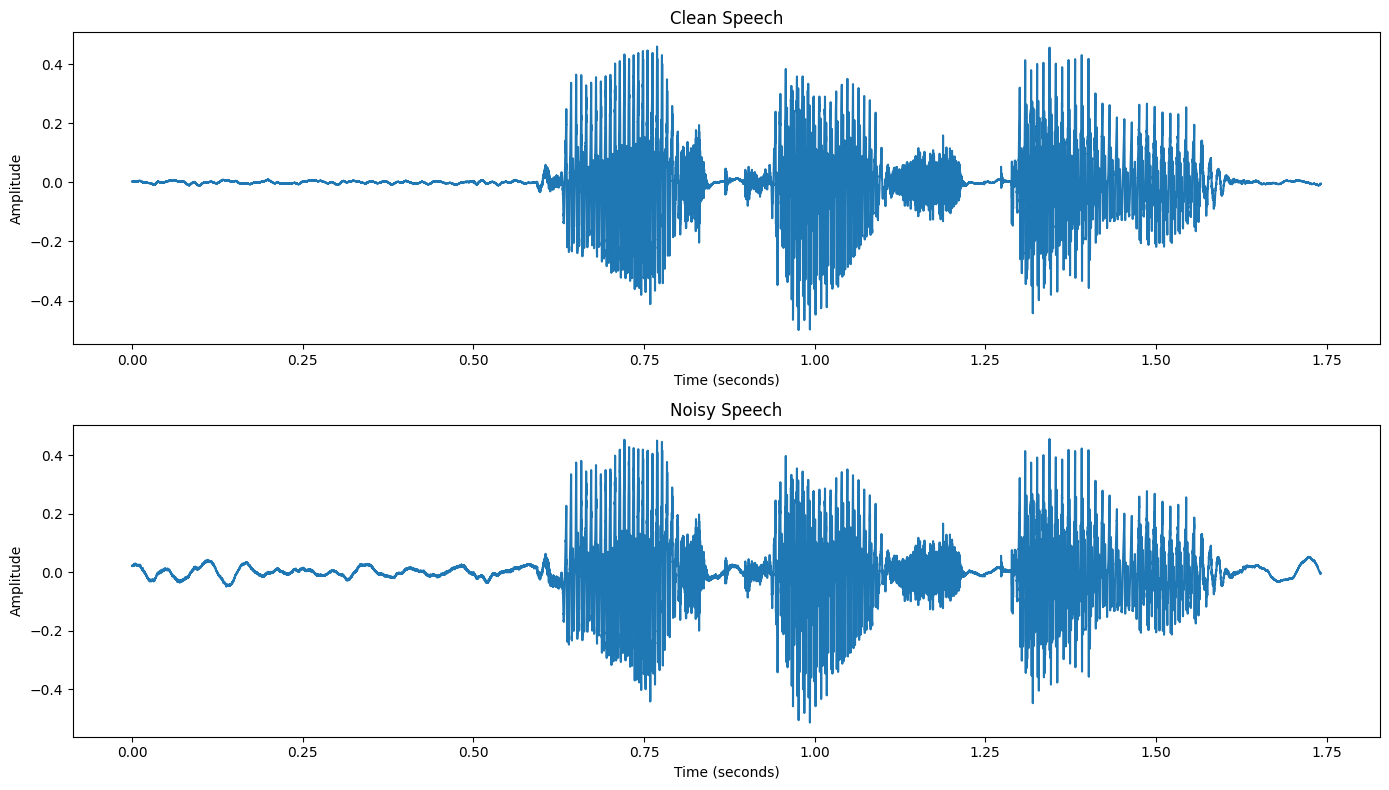

In [8]:
clean_time = np.arange(len(clean_audio)) / clean_sr
noisy_time = np.arange(len(noisy_audio)) / noisy_sr

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(clean_time, clean_audio)
axes[0].set_title("Clean Speech")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(noisy_time, noisy_audio)
axes[1].set_title("Noisy Speech")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [9]:
n_fft = 512
hop_length = 128

clean_stft = librosa.stft(
    clean_audio,
    n_fft=n_fft,
    hop_length=hop_length
)

noisy_stft = librosa.stft(
    noisy_audio,
    n_fft=n_fft,
    hop_length=hop_length
)

clean_db = librosa.amplitude_to_db(
    np.abs(clean_stft),
    ref=np.max
)

noisy_db = librosa.amplitude_to_db(
    np.abs(noisy_stft),
    ref=np.max
)

print("Clean STFT shape:", clean_stft.shape)
print("Noisy STFT shape:", noisy_stft.shape)

Clean STFT shape: (257, 653)
Noisy STFT shape: (257, 653)


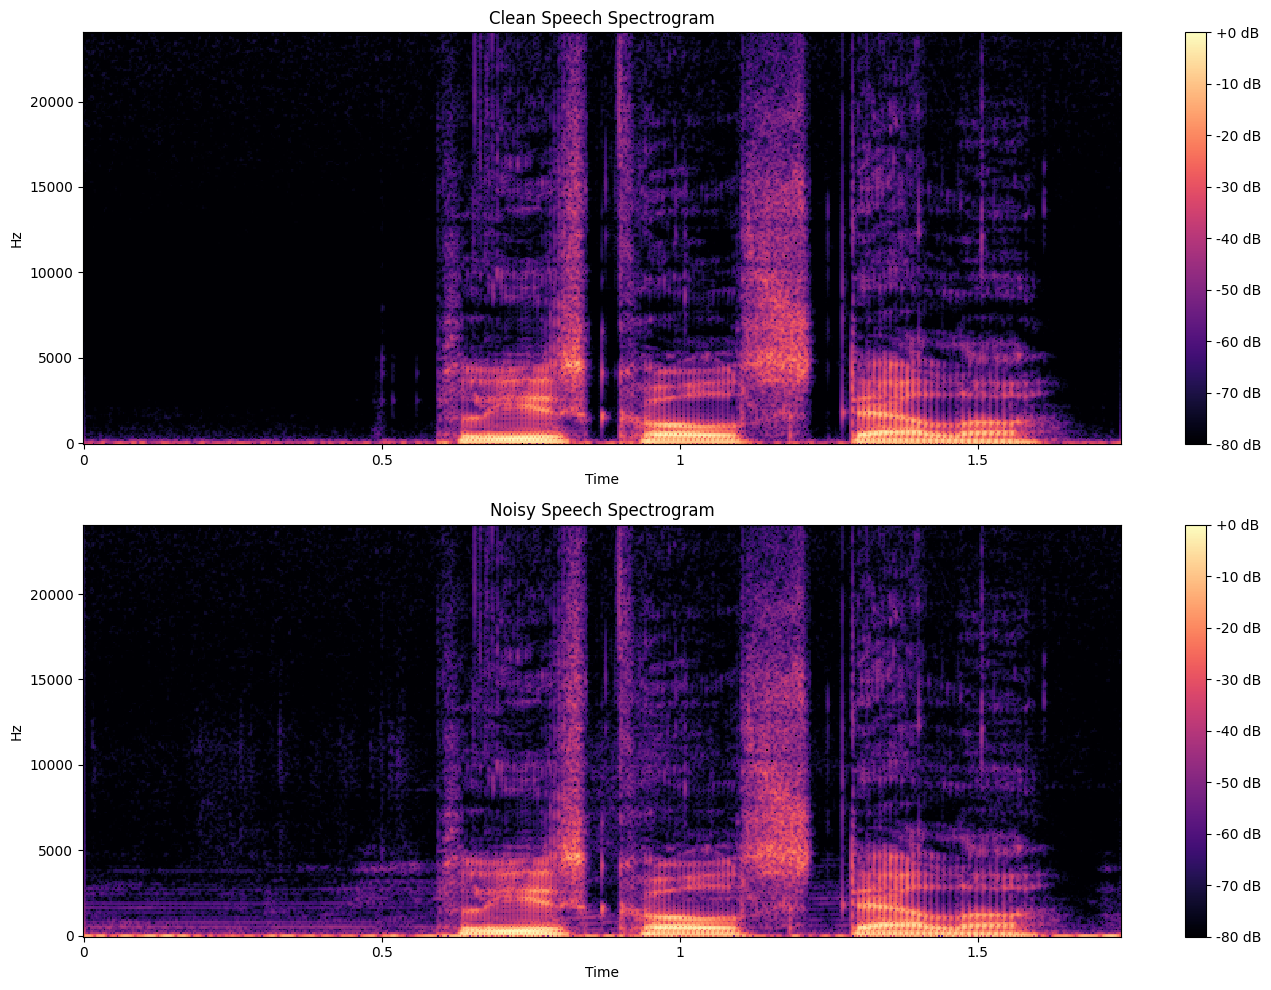

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

img1 = librosa.display.specshow(
    clean_db,
    sr=clean_sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=axes[0]
)

axes[0].set_title("Clean Speech Spectrogram")

fig.colorbar(
    img1,
    ax=axes[0],
    format="%+2.0f dB"
)

img2 = librosa.display.specshow(
    noisy_db,
    sr=noisy_sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=axes[1]
)

axes[1].set_title("Noisy Speech Spectrogram")

fig.colorbar(
    img2,
    ax=axes[1],
    format="%+2.0f dB"
)

plt.tight_layout()
plt.show()

In [11]:
print("Clean file:")
print(clean_path)

print("\nNoisy file:")
print(noisy_path)

print("\nAre the files identical?")
print(np.array_equal(clean_audio, noisy_audio))

noise = noisy_audio - clean_audio

print("\nNoise statistics:")
print("Maximum difference:", np.max(np.abs(noise)))
print("Mean absolute difference:", np.mean(np.abs(noise)))
print("Noise RMS:", np.sqrt(np.mean(noise ** 2)))

Clean file:
c:\Users\ohkab\audio-denoising\data\clean_test\p232_001.wav

Noisy file:
c:\Users\ohkab\audio-denoising\data\noisy_test\p232_001.wav

Are the files identical?
False

Noise statistics:
Maximum difference: 0.054962158203125
Mean absolute difference: 0.011574253199935767
Noise RMS: 0.015213927310697211


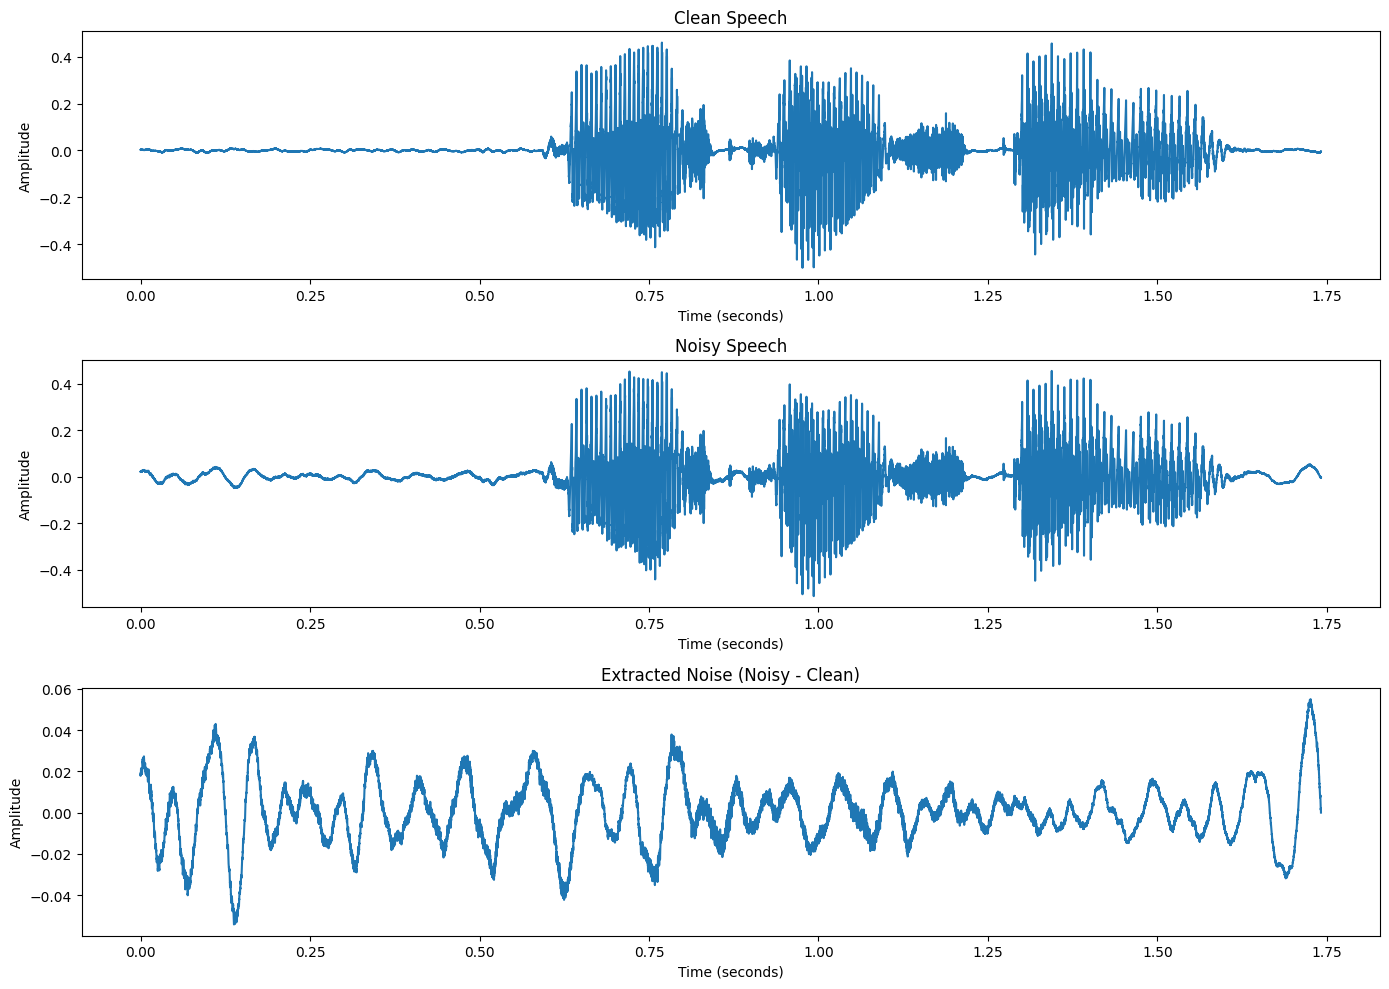

In [12]:
noise = noisy_audio - clean_audio

time = np.arange(len(clean_audio)) / clean_sr

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time, clean_audio)
axes[0].set_title("Clean Speech")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(time, noisy_audio)
axes[1].set_title("Noisy Speech")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")

axes[2].plot(time, noise)
axes[2].set_title("Extracted Noise (Noisy - Clean)")
axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [13]:
signal_power = np.mean(clean_audio ** 2)
noise_power = np.mean(noise ** 2)

snr_db = 10 * np.log10(signal_power / noise_power)

print(f"Signal power: {signal_power:.8f}")
print(f"Noise power: {noise_power:.8f}")
print(f"SNR: {snr_db:.2f} dB")

Signal power: 0.00817424
Noise power: 0.00023146
SNR: 15.48 dB


In [14]:
print("EXTRACTED NOISE")

display(
    Audio(
        noise,
        rate=clean_sr
    )
)

EXTRACTED NOISE


In [15]:
import random

sample_files = random.sample(clean_files, 5)

for clean_path in sample_files:

    noisy_path = noisy_dir / clean_path.name

    clean, sr = sf.read(clean_path)
    noisy, _ = sf.read(noisy_path)

    noise = noisy - clean

    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    snr = 10 * np.log10(signal_power / noise_power)

    print(
        f"{clean_path.name}: "
        f"SNR = {snr:.2f} dB"
    )

p257_324.wav: SNR = 16.64 dB
p257_232.wav: SNR = 16.65 dB
p257_335.wav: SNR = 0.46 dB
p257_034.wav: SNR = 0.76 dB
p257_434.wav: SNR = 0.30 dB


In [1]:
from pathlib import Path
import soundfile as sf

# Project root
project_root = Path.cwd().parent

# Training directories
train_clean_dir = project_root / "data" / "clean_train"
train_noisy_dir = project_root / "data" / "noisy_train"

# Find WAV files
train_clean_files = sorted(train_clean_dir.rglob("*.wav"))
train_noisy_files = sorted(train_noisy_dir.rglob("*.wav"))

print("Clean training files:", len(train_clean_files))
print("Noisy training files:", len(train_noisy_files))

Clean training files: 11572
Noisy training files: 11572


In [2]:
clean_names = {f.name for f in train_clean_files}
noisy_names = {f.name for f in train_noisy_files}

missing_noisy = clean_names - noisy_names
missing_clean = noisy_names - clean_names

print("Clean files:", len(clean_names))
print("Noisy files:", len(noisy_names))

print("Missing noisy files:", len(missing_noisy))
print("Missing clean files:", len(missing_clean))

if len(missing_noisy) == 0 and len(missing_clean) == 0:
    print("\n✓ All clean/noisy training pairs match.")
else:
    print("\n⚠ Some pairs are missing.")

Clean files: 11572
Noisy files: 11572
Missing noisy files: 0
Missing clean files: 0

✓ All clean/noisy training pairs match.


In [3]:
clean_file = train_clean_files[0]

# Find noisy file with same filename
noisy_file = train_noisy_dir / clean_file.name

clean_audio, clean_sr = sf.read(clean_file)
noisy_audio, noisy_sr = sf.read(noisy_file)

print("Clean file:", clean_file)
print("Noisy file:", noisy_file)

print("\nCLEAN")
print("Sample rate:", clean_sr)
print("Shape:", clean_audio.shape)
print("Duration:", len(clean_audio) / clean_sr)

print("\nNOISY")
print("Sample rate:", noisy_sr)
print("Shape:", noisy_audio.shape)
print("Duration:", len(noisy_audio) / noisy_sr)

Clean file: c:\Users\ohkab\audio-denoising\data\clean_train\p226_001.wav
Noisy file: c:\Users\ohkab\audio-denoising\data\noisy_train\p226_001.wav

CLEAN
Sample rate: 48000
Shape: (109440,)
Duration: 2.28

NOISY
Sample rate: 48000
Shape: (109440,)
Duration: 2.28


In [4]:
import numpy as np

min_len = min(len(clean_audio), len(noisy_audio))

clean_audio = clean_audio[:min_len]
noisy_audio = noisy_audio[:min_len]

noise = noisy_audio - clean_audio

noise_rms = np.sqrt(np.mean(noise ** 2))

signal_power = np.mean(clean_audio ** 2)
noise_power = np.mean(noise ** 2)

snr = 10 * np.log10(signal_power / noise_power)

print("Noise RMS:", noise_rms)
print(f"SNR: {snr:.2f} dB")

Noise RMS: 0.01583613601143108
SNR: 12.26 dB
